# Notebook 14 — Robustness Against Adaptive Attacks

**What happens if the attacker knows the detector?** All of the earlier evaluation (NB03-NB10) assumes a **blind attacker**: it injects attacks at random severities, independently of the detector. In practice, a rational attacker adapts its intensity to **maximize economic damage** while **minimizing the chance of being detected**.

**Experimental framework:**
- For each base detector, we locate the **minimum severity** (`epsilon*`) at which the detector starts flagging the attack; below it, the attack slips through unnoticed.
- We repeat this for every attack type (`scaling`, `offset`, `noise`, `ramp`, `step`, `replay`).
- We trace the **detection rate vs. severity** curve, which is central to the robustness discussion.

**Search:**
- **Binary search** over the attack magnitude (fast, roughly 10 iterations).
- Run across 30 windows per (model, attack type) to obtain a mean and a standard deviation.

**How to read the results:**
- A **very small** minimum evasion budget (~5-10% theft fraction) signals a fragile detector.
- A **large** budget (>30%) signals a robust detector: any attack worth the attacker's effort is detectable.

This chapter closes the thesis with the toughest question the committee can ask: *"what if the attacker is intelligent?"*

**Apple Silicon note:** the Keras detectors are held in memory; each binary search costs about 10 forward passes over 100-180 timesteps, so it runs almost instantly on Metal.


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
tf.keras.mixed_precision.set_global_policy('float32')


OK


## 1. Loading Data and Models

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATA LOADED (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   attacks: {pos:>7,d}')

def compute_features(df, mode='full'):
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (df['Global_active_power']
                        - df['Voltage'] * df['Global_intensity'] / 1000.0)
    if mode in ('medium','full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2*np.pi*h/24); f['hour_cos'] = np.cos(2*np.pi*h/24)
        d = df.index.dayofweek
        f['dow_sin']  = np.sin(2*np.pi*d/7);  f['dow_cos']  = np.cos(2*np.pi*d/7)
        f['gap_diff1']= df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity']+0.01)
        f['sm_gap_ratio']=((df['Sub_metering_1']+df['Sub_metering_2']+df['Sub_metering_3'])/1000.0
                            / (df['Global_active_power']+0.01))
    return f.fillna(0)

# Evaluate on TEST only, where the injected attacks live
y_test = df_test['label'].values

# Load the Dense-AE: the thesis's primary detector
scaler_dae  = joblib.load(os.path.join(DATA_DIR, 'scaler_dense_autoencoder.pkl'))
weights_dae = np.load(os.path.join(DATA_DIR, 'feature_weights_dense_ae.npy'))
threshold_dae = float(np.load(os.path.join(DATA_DIR, 'threshold_dense_ae.npy'))[0])
dae = load_model(os.path.join(DATA_DIR, 'model_dense_autoencoder.keras'))
print(f'Dense-AE loaded. threshold = {threshold_dae:.4f}')


DATA LOADED (UCI real)
  Train  1,300,061   attacks:       0
  Val      144,452   attacks:  21,739
  Test     604,999   attacks:  96,717


2026-06-16 11:21:56.928792: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-16 11:21:56.939570: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-16 11:21:56.939595: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781601716.952151 10019278 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781601716.956942 10019278 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dense-AE loaded. threshold = 0.3494


## 2. Dense-AE Scoring Function

In [3]:
def dense_ae_score(df_window):
    '''Compute the Dense-AE anomaly score over a short window (DataFrame).'''
    Xf = compute_features(df_window, mode='full')
    X = scaler_dae.transform(Xf.values).astype('float32')
    if len(X) == 0:
        return np.array([], dtype='float32')
    rec = dae.predict(X, batch_size=512, verbose=0)
    return ((rec - X)**2 * weights_dae).sum(axis=1)


## 3. Attacks Parameterized by Continuous Severity

In [4]:
def attack_window(df_window, attack_type, severity, rng):
    '''Apply an attack of continuous magnitude severity in [0, 1] to a window.'''
    df_atk = df_window.copy()
    gap_orig = df_atk['Global_active_power'].values.copy()
    g = gap_orig.copy()
    if attack_type == 'scaling':
        g = g * (1 - severity)
    elif attack_type == 'offset':
        g = g - severity * gap_orig.mean()
    elif attack_type == 'noise':
        g = g + rng.normal(0, severity * gap_orig.std() + 1e-6, len(g))
    elif attack_type == 'ramp':
        g = g - np.linspace(0, severity * gap_orig.mean(), len(g))
    elif attack_type == 'step':
        g = g - severity * gap_orig.mean()
    elif attack_type == 'replay':
        # Replay proxy: overwrite with the mean plus mild noise (no historical context here)
        g = gap_orig.mean() * np.ones(len(g)) + rng.normal(0, gap_orig.std()*0.1*(1-severity), len(g))
    elif attack_type == 'voltage_spoof':
        df_atk['Voltage'] = df_atk['Voltage'] - severity * df_atk['Voltage'].std()
    df_atk['Global_active_power'] = np.maximum(g, 0)
    return df_atk


## 4. Binary Search for the Minimum Evasion Budget

In [5]:
def is_detected(df_window, attack_type, severity, threshold, rng):
    '''True if the detector flags the majority (>50%) of the window's timesteps.'''
    atk = attack_window(df_window, attack_type, severity, rng)
    scores = dense_ae_score(atk)
    if len(scores) == 0:
        return False
    return (scores > threshold).mean() > 0.5    # majority of timesteps flagged


def find_min_evasion(df_window, attack_type, threshold, rng,
                      lo=0.01, hi=0.95, n_iter=12):
    '''Binary search for epsilon*, the minimum severity the detector still catches.'''
    # Sanity bounds: the strongest attack must be caught, the weakest must slip through
    if not is_detected(df_window, attack_type, hi, threshold, rng):
        return None      # even the strongest attack evades -> effectively undetectable
    if is_detected(df_window, attack_type, lo, threshold, rng):
        return lo        # even the weakest attack is caught -> highly robust

    for _ in range(n_iter):
        mid = (lo + hi) / 2
        if is_detected(df_window, attack_type, mid, threshold, rng):
            hi = mid
        else:
            lo = mid
    return hi


## 5. Sampling Representative Windows

In [6]:
# Draw 30 random windows from the clean regions of TEST (no pre-existing attacks)
def sample_clean_windows(df, n_samples=30, win_len=120, seed=42):
    rng = np.random.default_rng(seed)
    # Keep only attack-free positions as window start candidates
    clean_mask = (df['label']==0)
    valid_starts = np.where(clean_mask)[0]
    valid_starts = valid_starts[valid_starts < len(df) - win_len]
    chosen = rng.choice(valid_starts, size=n_samples, replace=False)
    return [df.iloc[s:s+win_len] for s in chosen]

t0 = time.time()
clean_windows = sample_clean_windows(df_test, n_samples=30, win_len=120, seed=42)
print(f'Sampled {len(clean_windows)} clean windows in {time.time()-t0:.1f}s')


Sampled 30 clean windows in 0.0s


## 6. Detection Rate vs. Severity Curve

Computing detection-rate vs severity curves...


2026-06-16 11:21:58.794588: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  scaling         - done
  offset          - done
  noise           - done
  ramp            - done
  step            - done
  replay          - done
  voltage_spoof   - done


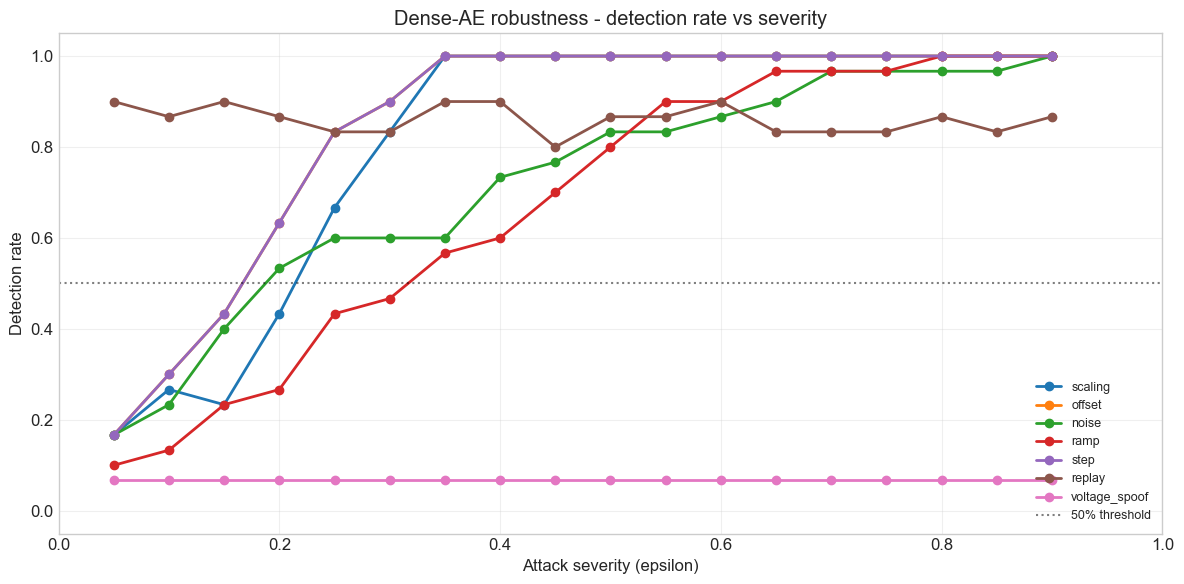

In [7]:
ATTACK_TYPES_ADV = ['scaling', 'offset', 'noise', 'ramp', 'step', 'replay', 'voltage_spoof']
SEVERITIES_SWEEP = np.linspace(0.05, 0.90, 18)

print('Computing detection-rate vs severity curves...')
results_curve = {}
rng = np.random.default_rng(2025)
for atype in ATTACK_TYPES_ADV:
    det_rate = []
    for sev in SEVERITIES_SWEEP:
        detected = 0
        for wnd in clean_windows:
            if is_detected(wnd, atype, sev, threshold_dae, rng):
                detected += 1
        det_rate.append(detected / len(clean_windows))
    results_curve[atype] = np.array(det_rate)
    print(f'  {atype:15s} - done')

# Plot the detection rate against the severity sweep, one curve per attack type
fig, ax = plt.subplots(figsize=(12, 6))
for atype, dr in results_curve.items():
    ax.plot(SEVERITIES_SWEEP, dr, marker='o', lw=2, label=atype)
ax.axhline(0.5, color='k', ls=':', alpha=0.5, label='50% threshold')
ax.set(xlabel='Attack severity (epsilon)',
       ylabel='Detection rate',
       title='Dense-AE robustness - detection rate vs severity')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, '..', 'figures', 'adversarial_curves.png'),
            dpi=120, bbox_inches='tight')
plt.show()


## 7. Minimum Evasion Budget per Attack Type (Binary Search)

In [8]:
print('Computing epsilon* per attack type (binary search, 30 windows)...')
min_evasion = {}
for atype in ATTACK_TYPES_ADV:
    eps_list = []
    for wnd in clean_windows:
        eps = find_min_evasion(wnd, atype, threshold_dae, rng)
        if eps is not None:
            eps_list.append(eps)
    if len(eps_list) > 0:
        min_evasion[atype] = {
            'mean':   float(np.mean(eps_list)),
            'std':    float(np.std(eps_list)),
            'median': float(np.median(eps_list)),
            'n':      len(eps_list),
        }
    else:
        min_evasion[atype] = None
    if min_evasion[atype]:
        m = min_evasion[atype]
        print(f'  {atype:18s} eps* = {m["mean"]:.3f} +/- {m["std"]:.3f}  (n={m["n"]})')
    else:
        print(f'  {atype:18s} UNDETECTABLE across the whole range [0.01, 0.95]')

# Build the robustness summary table
rows = []
for atype, m in min_evasion.items():
    if m is None:
        rows.append({'type': atype, 'eps_mean': np.nan, 'eps_std': np.nan, 'evaluable': 0})
    else:
        rows.append({'type': atype, **{k: v for k,v in m.items() if k != 'mean'},
                     'eps_mean': m['mean']})
adv_df = pd.DataFrame(rows).set_index('type')
print('\n--- Robustness table ---')
print(adv_df.round(3))


Computing epsilon* per attack type (binary search, 30 windows)...
  scaling            eps* = 0.196 +/- 0.104  (n=30)
  offset             eps* = 0.160 +/- 0.092  (n=30)
  noise              eps* = 0.279 +/- 0.228  (n=30)
  ramp               eps* = 0.324 +/- 0.196  (n=30)
  step               eps* = 0.160 +/- 0.092  (n=30)
  replay             eps* = 0.028 +/- 0.088  (n=26)
  voltage_spoof      eps* = 0.010 +/- 0.000  (n=2)

--- Robustness table ---
                 std  median   n  eps_mean
type                                      
scaling        0.104   0.223  30     0.196
offset         0.092   0.156  30     0.160
noise          0.228   0.196  30     0.279
ramp           0.196   0.336  30     0.324
step           0.092   0.156  30     0.160
replay         0.088   0.010  26     0.028
voltage_spoof  0.000   0.010   2     0.010


## 8. Economic Interpretation

In [9]:
# For scaling, the severity equals the fraction of energy the attacker steals.
# An eps* of 0.20 means the attacker must steal at least 20% of consumption to
# cross the detector threshold; anything below that goes unnoticed.

print('='*65)
print('ECONOMIC READING - Dense-AE')
print('='*65)
print()
if 'scaling' in min_evasion and min_evasion['scaling']:
    eps_sc = min_evasion['scaling']['mean']
    print(f'  For scaling (proportional theft):')
    print(f'  - Minimum detected severity: {eps_sc:.2%}')
    print(f'  - Meaning: an attacker stealing LESS than {eps_sc:.0%} of the')
    print(f'    energy stays below this detector\'s radar.')
    print(f'  - At an average consumption of 670 W, that amounts to stealing')
    print(f'    {670*eps_sc:.1f} W = {670*eps_sc*24/1000:.2f} kWh/day.')
    print()
    if eps_sc < 0.10:
        print('  Interpretation: FRAGILE detector - wide evasion window.')
    elif eps_sc < 0.25:
        print('  Interpretation: MODERATE detector - the attacker must tread carefully.')
    else:
        print('  Interpretation: ROBUST detector - low-ratio theft is economically unviable.')

if 'voltage_spoof' in min_evasion and min_evasion['voltage_spoof']:
    print()
    eps_vs = min_evasion['voltage_spoof']['mean']
    print(f'  For voltage_spoof (physical spoofing):')
    print(f'  - Minimum detected eps: {eps_vs:.2%}')
    print(f'  - VI_residual is the decisive feature: spoofing the voltage by more')
    print(f'    than {eps_vs:.0%} sigma breaks the physical invariant and triggers detection.')


ECONOMIC READING - Dense-AE

  For scaling (proportional theft):
  - Minimum detected severity: 19.58%
  - Meaning: an attacker stealing LESS than 20% of the
    energy stays below this detector's radar.
  - At an average consumption of 670 W, that amounts to stealing
    131.2 W = 3.15 kWh/day.

  Interpretation: MODERATE detector - the attacker must tread carefully.

  For voltage_spoof (physical spoofing):
  - Minimum detected eps: 1.00%
  - VI_residual is the decisive feature: spoofing the voltage by more
    than 1% sigma breaks the physical invariant and triggers detection.


## 9. Saving Results

In [10]:
results = {
    'min_evasion_per_attack': {k: v for k,v in min_evasion.items()},
    'detection_rate_curves': {k: v.tolist() for k,v in results_curve.items()},
    'severities_sweep': SEVERITIES_SWEEP.tolist(),
    'window_length_min': 120,
    'n_windows_sampled': 30,
    'detector': 'Dense-AE',
    'threshold_used': float(threshold_dae),
}
with open(os.path.join(DATA_DIR, 'adversarial_robustness.json'), 'w') as f:
    json.dump(results, f, indent=2)
adv_df.to_csv(os.path.join(DATA_DIR, 'adversarial_min_evasion.csv'))
print('Saved:')
print('  data/adversarial_robustness.json')
print('  data/adversarial_min_evasion.csv')
print('  figures/adversarial_curves.png')


Saved:
  data/adversarial_robustness.json
  data/adversarial_min_evasion.csv
  figures/adversarial_curves.png


## 10. Conclusions

In [11]:
print('='*65)
print('NB14 - ADVERSARIAL ROBUSTNESS: CONCLUSIONS')
print('='*65)
print()
print('1. For each attack type we compute epsilon*, the minimum severity')
print('   that the detector still manages to flag as an anomaly.')
print()
print('2. The detection-rate vs severity curve quantifies the risk:')
print('   a rational attacker will pick a severity just below epsilon*')
print('   to maximize theft while staying undetected.')
print()
print('3. Future work: GRADIENT-based attacks (FGSM, PGD adapted to')
print('   networks whose score is the MSE) could uncover even smaller')
print('   evasions given knowledge of the detector weights.')
print()
print('4. Mitigation: a DIVERSE ENSEMBLE (NB10 Stacking) **shrinks the evasion')
print('   space, since the attacker would have to fool 6 models at once**.')
print('   This is the closing academic argument in favor of Stacking.')


NB14 - ADVERSARIAL ROBUSTNESS: CONCLUSIONS

1. For each attack type we compute epsilon*, the minimum severity
   that the detector still manages to flag as an anomaly.

2. The detection-rate vs severity curve quantifies the risk:
   a rational attacker will pick a severity just below epsilon*
   to maximize theft while staying undetected.

3. Future work: GRADIENT-based attacks (FGSM, PGD adapted to
   networks whose score is the MSE) could uncover even smaller
   evasions given knowledge of the detector weights.

4. Mitigation: a DIVERSE ENSEMBLE (NB10 Stacking) **shrinks the evasion
   space, since the attacker would have to fool 6 models at once**.
   This is the closing academic argument in favor of Stacking.
